## TP N°1 - Gestión y Mantenimiento Electromecánico (UTN FRSR)
### Línea Principal de Elevación y Transporte de Áridos de Alta Densidad

> **Ingeniería de Confiabilidad, Diagnóstico de Parámetros Operativos, Tareas de Inspección y Estrategias de Mantenimiento.**

Este notebook procesa los registros de fallas del último ciclo anual (7.200 h programadas), calcula los KPIs de confiabilidad (MTBF / MTTR / Ai / Ao), construye la Matriz de Criticidad de los 5 subsistemas, genera el dashboard 2×2 y exporta el informe profesional a Excel.

---

**Contenido:** 1) Datos de entrada &nbsp;·&nbsp; 2) Registro económico &nbsp;·&nbsp; 3) KPIs &nbsp;·&nbsp; 4) Matriz de Criticidad &nbsp;·&nbsp; 5) Dashboard &nbsp;·&nbsp; 6) Exportación a Excel.

In [1]:
# =====================================================================
# CELDA: Importación de librerías y configuración global de estilos
# =====================================================================
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from pathlib import Path

# --- Estética global (calidad para informe / dashboard) ---------------
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.dpi": 120,                      # resolución alta (impresión / PDF)
    "font.family": "DejaVu Sans",           # compatible con acentos del español
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.30,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.autolayout": True,
})
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

## 1. Datos de entrada

Datos del enunciado: 5 eventos de falla (F1–F5) con su tiempo de parada (TTP), costo de repuestos y horas-hombre. Se incluyen las constantes económicas del TP (2.500 USD/h de parada y 25 USD/HH).

In [2]:
# =====================================================================
# CELDA: DATOS DE ENTRADA DEL TP N°1  (bloque editable por el alumno)
# =====================================================================
# Parámetros de diseño y económicos del activo (según enunciado del TP)
TOP_HORAS    = 7200.0   # Tiempo Operativo Programado anual [h]  (24 h/dia x 300 dias)
N_FALLAS     = 5        # Cantidad de eventos de falla registrados
COSTO_PARADA = 2500.0   # Costo de parada de planta [USD/h]  (lucro cesante + costo fijo)
COSTO_HH     = 25.0     # Costo horario de mano de obra propia de mantenimiento [USD/HH]

# Registro de los 5 eventos de falla (F1 a F5) del ultimo ciclo anual.
#   ttp        = Tiempo Total de Parada asociado al evento [h]
#   repuestos  = Costo de materiales / repuestos [USD]
#   hh         = Horas-hombre de mantenimiento invertidas
DATOS_FALLAS = [
    {"evento": "F1",
     "subsistema": "Polea Motriz y Apoyos",
     "componente": "Rodamiento oscilante 22220 EK (lado acoplamiento)",
     "descripcion": "Picado/spalling en pista exterior por contaminacion con material "
                    "abrasivo y degradacion de grasa. Requirio desmontaje completo de la polea motriz.",
     "ttp": 28.0, "repuestos": 1850.0, "hh": 48.0},

    {"evento": "F2",
     "subsistema": "Unidad Motriz",
     "componente": "Motor asincronico trifasico 55 kW (4 polos, 380/660 V)",
     "descripcion": "Sobrecalentamiento y cortocircuito entre espiras del estator por bloqueo "
                    "del ventilador y acumulacion de polvo en carcasa. Requirio rebobinado completo.",
     "ttp": 42.0, "repuestos": 3400.0, "hh": 24.0},

    {"evento": "F3",
     "subsistema": "Sistema de Tensionado y Control",
     "componente": "Latiguillo de alta presion / centralita oleohidraulica (20 bar)",
     "descripcion": "Fuga masiva de fluido hidraulico por fisura del latiguillo por fatiga de "
                    "pulsacion; caida de presion en el tensionado y disparo del interbloqueo.",
     "ttp": 6.0, "repuestos": 320.0, "hh": 12.0},

    {"evento": "F4",
     "subsistema": "Banda y Tambor de Reenvio",
     "componente": "Cinta transportadora (rasgado longitudinal de 15 m de goma superior)",
     "descripcion": "Desalineacion severa por acumulacion de material en tambor de reenvio, con "
                    "rasgado longitudinal. Requirio vulcanizado en caliente por terceros.",
     "ttp": 36.0, "repuestos": 4200.0, "hh": 36.0},

    {"evento": "F5",
     "subsistema": "Limpieza y Proteccion",
     "componente": "Rascador primario de uretano",
     "descripcion": "Desgaste prematuro y atrancamiento del rascador por friccion contra la banda, "
                    "con sobrecarga termica del reductor y aumento de corriente del motor.",
     "ttp": 8.0, "repuestos": 450.0, "hh": 16.0},
]

## 2. Registro económico de fallas

Tabla con columnas derivadas: **Costo Parada = TTP × 2.500**, **Costo MO = HH × 25** y **Costo Total**, más la fila de TOTALES del ciclo.

In [3]:
# =====================================================================
# CELDA: DATAFRAME ECONOMICO DE LAS FALLAS (columnas derivadas + TOTAL)
# =====================================================================
df_fallas = pd.DataFrame(DATOS_FALLAS)

# Impacto economico derivado (consigna 5 del TP):
#   Costo_Parada = TTP [h] * 2.500 [USD/h]  -> lucro cesante + costo operativo fijo
#   Costo_MO     = HH * 25 [USD/HH]         -> mano de obra propia de mantenimiento
df_fallas["Costo_Parada_USD"] = df_fallas["ttp"] * COSTO_PARADA
df_fallas["Costo_MO_USD"]     = df_fallas["hh"] * COSTO_HH
df_fallas["Costo_Total_USD"]  = (df_fallas["Costo_Parada_USD"]
                                 + df_fallas["repuestos"]
                                 + df_fallas["Costo_MO_USD"])

# Fila TOTAL acumulada del ciclo anual
fila_total = {
    "evento": "TOTAL",
    "subsistema": "",
    "componente": "",
    "descripcion": "Sumatoria del ciclo anual",
    "ttp":        df_fallas["ttp"].sum(),
    "repuestos":  df_fallas["repuestos"].sum(),
    "hh":         df_fallas["hh"].sum(),
    "Costo_Parada_USD": df_fallas["Costo_Parada_USD"].sum(),
    "Costo_MO_USD":     df_fallas["Costo_MO_USD"].sum(),
    "Costo_Total_USD":  df_fallas["Costo_Total_USD"].sum(),
}
df_finanzas = pd.concat([df_fallas, pd.DataFrame([fila_total])], ignore_index=True)

print("=" * 104)
print("REGISTRO DE FALLAS Y EVALUACION ECONOMICA - LINEA DE TRANSPORTE DE ARIDOS (UTN FRSR)")
print("=" * 104)
print(f"{'Evento':<7}{'TTP[h]':>8}{'Repuestos[USD]':>17}{'Parada[USD]':>17}"
      f"{'MO[USD]':>13}{'TOTAL[USD]':>17}")
print("-" * 104)
for _, r in df_finanzas.iterrows():
    tag = r["evento"]
    print(f"{tag:<7}{r['ttp']:>8,.0f}{r['repuestos']:>17,.2f}{r['Costo_Parada_USD']:>17,.2f}"
          f"{r['Costo_MO_USD']:>13,.2f}{r['Costo_Total_USD']:>17,.2f}")
print("=" * 104)

REGISTRO DE FALLAS Y EVALUACION ECONOMICA - LINEA DE TRANSPORTE DE ARIDOS (UTN FRSR)
Evento   TTP[h]   Repuestos[USD]      Parada[USD]      MO[USD]       TOTAL[USD]
--------------------------------------------------------------------------------------------------------
F1           28         1,850.00        70,000.00     1,200.00        73,050.00
F2           42         3,400.00       105,000.00       600.00       109,000.00
F3            6           320.00        15,000.00       300.00        15,620.00
F4           36         4,200.00        90,000.00       900.00        95,100.00
F5            8           450.00        20,000.00       400.00        20,850.00
TOTAL       120        10,220.00       300,000.00     3,400.00       313,620.00


## 3. KPIs de Confiabilidad y Disponibilidad

Fórmulas según el **ANEXO** del TP: MTBF = TFR/N, MTTR = TTP/N, Ai = MTBF/(MTBF+MTTR) y Ao = TFR/TOP.

In [4]:
# =====================================================================
# CELDA: KPIs DE CONFIABILIDAD Y DISPONIBILIDAD  (formulas del ANEXO)
# =====================================================================
TTP_total = df_fallas["ttp"].sum()                # Tiempo Total de Paradas [h]
TFR       = TOP_HORAS - TTP_total                # Tiempo de Funcionamiento Real [h]
MTBF      = TFR / N_FALLAS                        # Tiempo Medio Entre Fallas [h]
MTTR      = TTP_total / N_FALLAS                  # Tiempo Medio Para Reparar [h]
Ai        = MTBF / (MTBF + MTTR) * 100            # Disponibilidad Inherente [%]
Ao        = TFR / TOP_HORAS * 100                 # Disponibilidad Operacional [%]

print("=" * 104)
print("K P I s   -   C O N F I A B I L I D A D   Y   D I S P O N I B I L I D A D")
print("=" * 104)
kpis = [
    ("Tiempo Operativo Programado (TOP)", TOP_HORAS, "h",      "24 h/dia x 300 dias/año (dato de diseño)"),
    ("Tiempo Total de Paradas (TTP)",     TTP_total, "h",      "Sumatoria de los tiempos de reparacion F1-F5"),
    ("Tiempo de Funcionamiento Real (TFR)", TFR,    "h",      "TFR = TOP - TTP"),
    ("Cantidad de Fallas (N)",            N_FALLAS,  "fallas", "Eventos registrados en el ciclo anual"),
    ("MTBF  (Tiempo Medio Entre Fallas)", MTBF,      "h",      "MTBF = TFR / N  (aplica a sistemas reparables)"),
    ("MTTR  (Tiempo Medio Para Reparar)", MTTR,      "h",      "MTTR = TTP / N"),
    ("Disponibilidad Inherente (Ai)",     Ai,        "%",      "Ai = MTBF / (MTBF + MTTR)  [condiciones ideales]"),
    ("Disponibilidad Operacional (Ao)",   Ao,        "%",      "Ao = TFR / TOP  [gestion real del activo]"),
]
for nombre, valor, unidad, formula in kpis:
    if unidad == "%":
        print(f"{nombre:<40}{valor:>10.2f} {unidad:<8}| {formula}")
    else:
        print(f"{nombre:<40}{valor:>10,.2f} {unidad:<8}| {formula}")
print("-" * 104)

# --- Interpretacion tecnica -------------------------------------------------
print("Nota Tecnica 1: Ai == Ao en este ciclo porque NO hubo paradas de mantenimiento")
print("preventivo: la totalidad de las horas fuera de servicio correspondio a reparacion.")
print("Nota Tecnica 2: los eventos son independientes; asumir tiempo de reparacion")
print("equivalente al TTP de cada evento (diagnostico, reparacion, prueba y puesta en marcha).")
print("Nota Tecnica 3: el indicador correcto del motor como repuesto indivisible seria el")
print("MTTF (componente no reparable), pero el sistema completo es reparable -> se usa MTBF.")
print("=" * 104)

K P I s   -   C O N F I A B I L I D A D   Y   D I S P O N I B I L I D A D
Tiempo Operativo Programado (TOP)         7,200.00 h       | 24 h/dia x 300 dias/año (dato de diseño)
Tiempo Total de Paradas (TTP)               120.00 h       | Sumatoria de los tiempos de reparacion F1-F5
Tiempo de Funcionamiento Real (TFR)       7,080.00 h       | TFR = TOP - TTP
Cantidad de Fallas (N)                        5.00 fallas  | Eventos registrados en el ciclo anual
MTBF  (Tiempo Medio Entre Fallas)         1,416.00 h       | MTBF = TFR / N  (aplica a sistemas reparables)
MTTR  (Tiempo Medio Para Reparar)            24.00 h       | MTTR = TTP / N
Disponibilidad Inherente (Ai)                98.33 %       | Ai = MTBF / (MTBF + MTTR)  [condiciones ideales]
Disponibilidad Operacional (Ao)              98.33 %       | Ao = TFR / TOP  [gestion real del activo]
--------------------------------------------------------------------------------------------------------
Nota Tecnica 1: Ai == Ao en este ciclo p

## 4. Matriz de Criticidad de los 5 Subsistemas

Con Frecuencia (F) y Consecuencia Ci = S+A+O+D, Criticidad Total C = F×Ci y clasificación Clase A (≥15), B (10–14) o C (<10).

In [5]:
# =====================================================================
# CELDA: MATRIZ DE CRITICIDAD DE LOS 5 SUBSISTEMAS  (consigna 1b)
# =====================================================================
# Escalas del enunciado (editables segun justificacion del grupo):
#   F (Frecuencia): 1 Rara | 2 Ocasional | 3 Frecuente | 4 Muy frecuente
#   S (Seguridad) : 1 Sin riesgo | 2 Lesion menor | 3 Accidente grave
#   A (Ambiente)  : 1 Sin impacto | 2 Impacto menor | 3 Contaminacion severa de proceso
#   O (Operacional): 1 Sin parada | 3 Parada parcial | 10 Parada total c/ petrificacion
#   D (Costo directo de reparacion): 1 < $1.000 | 2 $1.000-$3.000 | 4 > $3.000
CRITICIDAD = [
    {"subsistema": "Unidad Motriz",              "componente": "Motor asincronico 55 kW",
     "evento": "F2", "F": 1, "S": 2, "A": 2, "O": 10, "D": 4},
    {"subsistema": "Banda y Tambor de Reenvio",  "componente": "Cinta transportadora (15 m rasgados)",
     "evento": "F4", "F": 1, "S": 2, "A": 2, "O": 10, "D": 4},
    {"subsistema": "Polea Motriz y Apoyos",      "componente": "Rodamiento oscilante 22220 EK",
     "evento": "F1", "F": 1, "S": 2, "A": 2, "O": 10, "D": 2},
    {"subsistema": "Sistema de Tensionado y Control", "componente": "Latiguillo HP / centralita oleohidraulica",
     "evento": "F3", "F": 1, "S": 2, "A": 3, "O": 10, "D": 1},
    {"subsistema": "Limpieza y Proteccion",      "componente": "Rascador primario de uretano",
     "evento": "F5", "F": 1, "S": 1, "A": 1, "O": 3,  "D": 1},
]


def asignar_clase(c):
    """Clasifica la criticidad segun C = F * Ci (criterio del TP)."""
    if c >= 15:
        return ("Clase A - CRITICO",
                "Alta Disponibilidad: monitoreo continuo + overhaul programado")
    if c >= 10:
        return ("Clase B - SEMICRITICO",
                "Sistematico / Predictivo: re-lubricacion y mediciones por calendario/condicion")
    return ("Clase C - NO CRITICO",
            "Condicional / TPM: inspeccion CIL por operador y atencion a la falla")


filas_matriz = []
for s in CRITICIDAD:
    ci = s["S"] + s["A"] + s["O"] + s["D"]      # Consecuencia total
    c  = s["F"] * ci                            # Criticidad Total
    clase, modelo = asignar_clase(c)
    filas_matriz.append({**s, "Ci": ci, "Criticidad_C": c,
                         "Clase": clase, "Modelo_Asignado": modelo})

df_matriz = pd.DataFrame(filas_matriz)

print("=" * 132)
print("MATRIZ DE CRITICIDAD - FRECUENCIA x CONSECUENCIA  (C = F x Ci)")
print("=" * 132)
print(f"{'Subsistema':<32}{'Evento':<8}{'F':>3}{'S':>4}{'A':>4}{'O':>4}{'D':>4}"
      f"{'Ci':>5}{'C':>5}  {'Clasificacion':<24}Modelo asignado")
print("-" * 132)
for _, r in df_matriz.iterrows():
    print(f"{r['subsistema']:<32}{r['evento']:<8}{r['F']:>3.0f}{r['S']:>4.0f}{r['A']:>4.0f}"
          f"{r['O']:>4.0f}{r['D']:>4.0f}{r['Ci']:>5.0f}{r['Criticidad_C']:>5.0f}"
          f"{'':>2}{r['Clase']:<24}{r['Modelo_Asignado']}")
print("=" * 132)
print("Distribucion: " + "; ".join(f"{c} = {n}"
      for c, n in df_matriz["Clase"].value_counts().sort_index().items()))

MATRIZ DE CRITICIDAD - FRECUENCIA x CONSECUENCIA  (C = F x Ci)
Subsistema                      Evento    F   S   A   O   D   Ci    C  Clasificacion           Modelo asignado
------------------------------------------------------------------------------------------------------------------------------------
Unidad Motriz                   F2        1   2   2  10   4   18   18  Clase A - CRITICO       Alta Disponibilidad: monitoreo continuo + overhaul programado
Banda y Tambor de Reenvio       F4        1   2   2  10   4   18   18  Clase A - CRITICO       Alta Disponibilidad: monitoreo continuo + overhaul programado
Polea Motriz y Apoyos           F1        1   2   2  10   2   16   16  Clase A - CRITICO       Alta Disponibilidad: monitoreo continuo + overhaul programado
Sistema de Tensionado y Control F3        1   2   3  10   1   16   16  Clase A - CRITICO       Alta Disponibilidad: monitoreo continuo + overhaul programado
Limpieza y Proteccion           F5        1   1   1   3   1    6 

## 5. Dashboard multipanel (2×2)

Pareto de costos, MTTR por evento, matriz frecuencia vs. consecuencia y estructura de costos global.

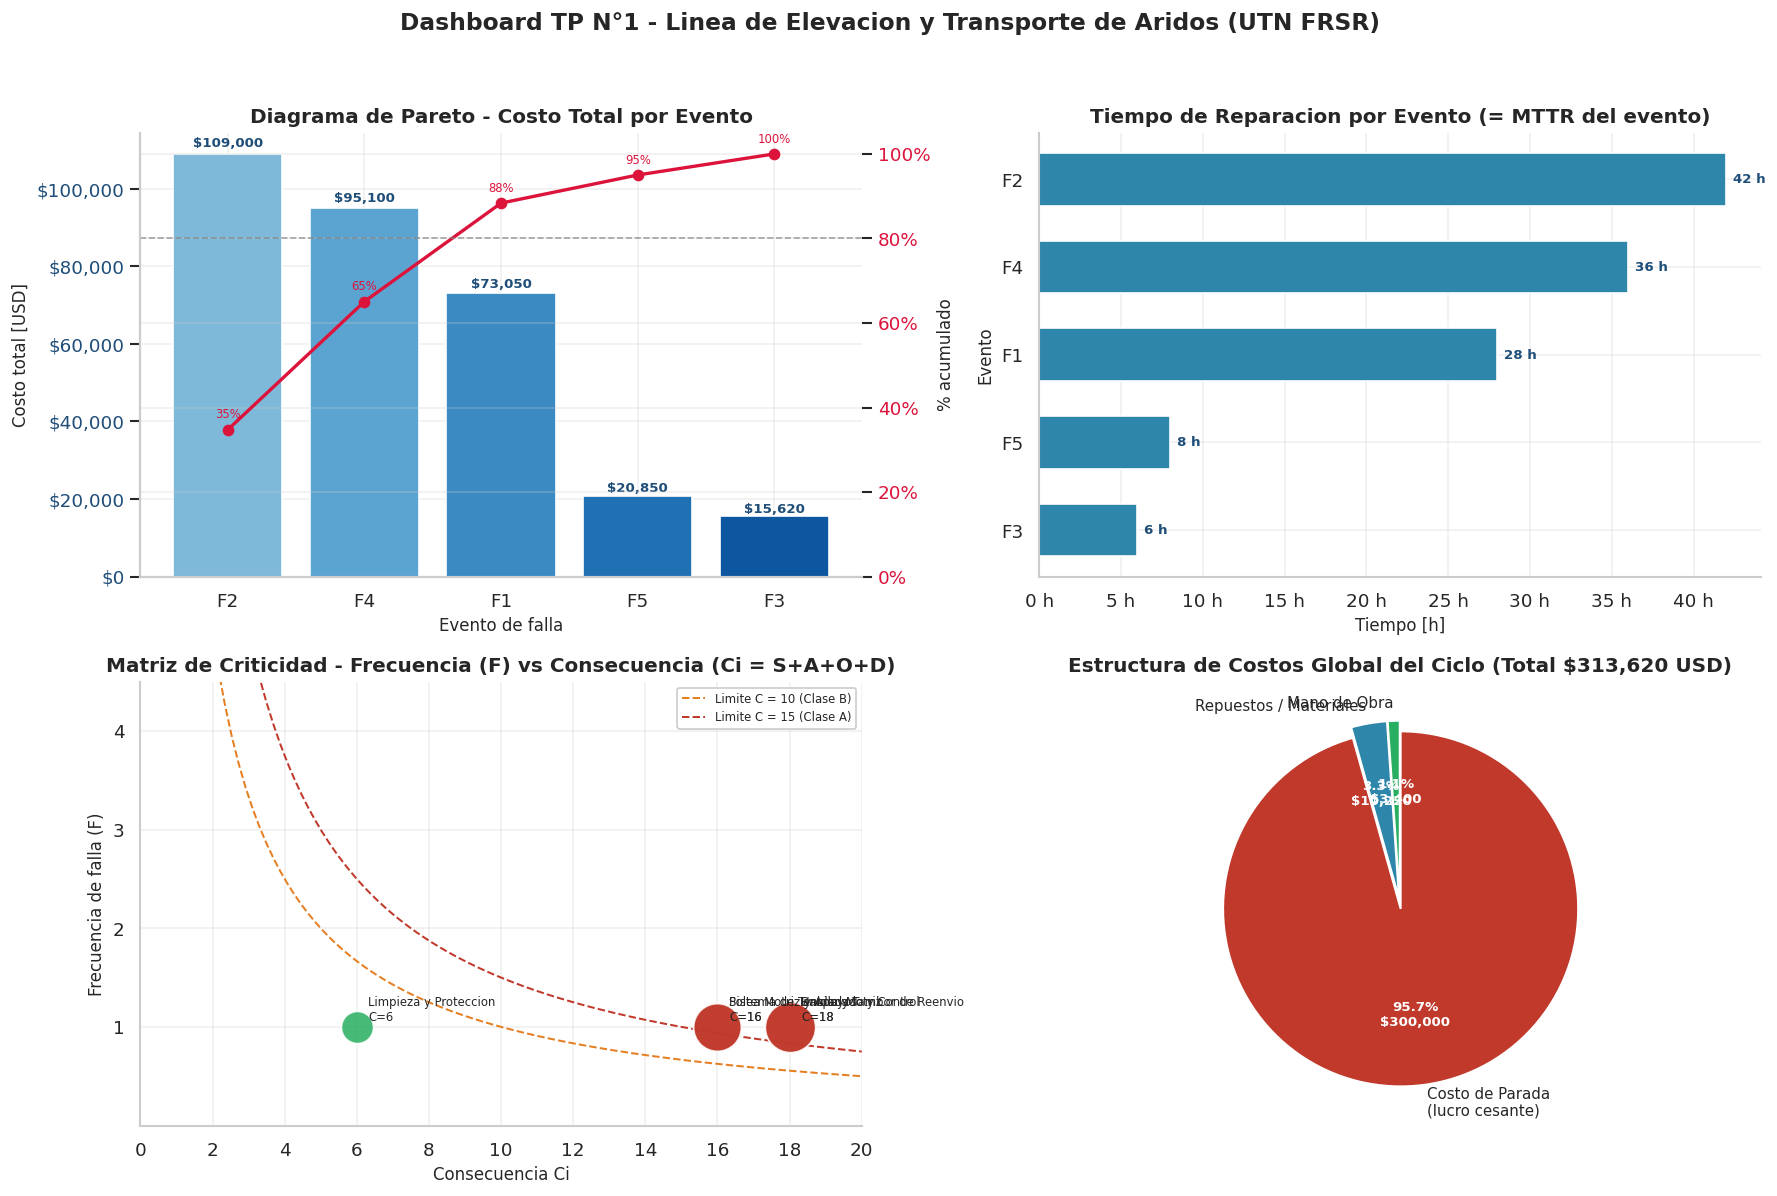

In [6]:
# =====================================================================
# CELDA: DASHBOARD MULTIPANEL 2x2  (Pareto / MTTR / Criticidad / Costos)
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Dashboard TP N°1 - Linea de Elevacion y Transporte de Aridos (UTN FRSR)",
             fontsize=14, fontweight="bold", y=0.995)

# ---------- Grafico 1: Diagrama de Pareto (Costo Total por Evento) ---------
ax1 = axes[0, 0]
dfp  = df_fallas.sort_values("Costo_Total_USD", ascending=False).reset_index(drop=True)
ax1.bar(dfp["evento"], dfp["Costo_Total_USD"],
        color=plt.cm.Blues(np.linspace(0.45, 0.85, len(dfp))), edgecolor="white")
ax1.set_title("Diagrama de Pareto - Costo Total por Evento")
ax1.set_xlabel("Evento de falla"); ax1.set_ylabel("Costo total [USD]")
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))

# Curva de % acumulado sobre eje secundario (regla 80/20)
cum    = dfp["Costo_Total_USD"].cumsum()
cum_pc = cum / dfp["Costo_Total_USD"].sum() * 100
axr = ax1.twinx()
axr.plot(dfp["evento"], cum_pc, "o-", color="crimson", lw=2, ms=6, label="% acumulado")
axr.axhline(80, color="gray", ls="--", lw=1, alpha=0.7)
axr.set_ylim(0, 105); axr.set_ylabel("% acumulado")
axr.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
for i, (ev, tot, cp) in enumerate(zip(dfp["evento"], dfp["Costo_Total_USD"], cum_pc)):
    ax1.text(i, tot * 1.01, f"${tot:,.0f}", ha="center", va="bottom",
             fontsize=8, fontweight="bold", color="#1f4e79")
    axr.annotate(f"{cp:.0f}%", (i, cp), textcoords="offset points", xytext=(0, 7),
                 ha="center", fontsize=7, color="crimson")
ax1.tick_params(axis="y", labelcolor="#1f4e79"); axr.tick_params(axis="y", labelcolor="crimson")

# ---------- Grafico 2: MTTR por evento (barras horizontales) ---------------
ax2 = axes[0, 1]
dfm = df_fallas.sort_values("ttp", ascending=True)
ax2.barh(dfm["evento"], dfm["ttp"], color="#2e86ab", edgecolor="white", height=0.6)
ax2.set_title("Tiempo de Reparacion por Evento (= MTTR del evento)")
ax2.set_xlabel("Tiempo [h]"); ax2.set_ylabel("Evento")
ax2.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f} h"))
for i, v in enumerate(dfm["ttp"]):
    ax2.text(v + 0.4, i, f"{v:.0f} h", va="center", fontsize=8, fontweight="bold", color="#1f4e79")

# ---------- Grafico 3: Criticidad Frecuencia vs Consecuencia ---------------
ax3 = axes[1, 0]
color_clase = {"Clase A - CRITICO": "#c0392b", "Clase B - SEMICRITICO": "#e67e22",
               "Clase C - NO CRITICO": "#27ae60"}
for _, r in df_matriz.iterrows():
    ax3.scatter(r["Ci"], r["F"], s=r["Criticidad_C"] * 45 + 100,
                color=color_clase[r["Clase"]], edgecolor="white", alpha=0.85, zorder=3)
    ax3.annotate(f"{r['subsistema']}\nC={r['Criticidad_C']:.0f}", (r["Ci"], r["F"]),
                 xytext=(7, 4), textcoords="offset points", fontsize=7)

# Curvas de isocriticidad de referencia (limites de clase C = 10 y C = 15)
ci_rango = np.linspace(1, 20, 100)
ax3.plot(ci_rango, 10 / ci_rango, ls="--", color="#e67e22", lw=1.2, label="Limite C = 10 (Clase B)")
ax3.plot(ci_rango, 15 / ci_rango, ls="--", color="#c0392b", lw=1.2, label="Limite C = 15 (Clase A)")
ax3.set_xlim(0, 20); ax3.set_ylim(0, 4.5)
ax3.set_yticks([1, 2, 3, 4]); ax3.set_xticks(range(0, 21, 2))
ax3.set_title("Matriz de Criticidad - Frecuencia (F) vs Consecuencia (Ci = S+A+O+D)")
ax3.set_xlabel("Consecuencia Ci"); ax3.set_ylabel("Frecuencia de falla (F)")
ax3.legend(loc="upper right", fontsize=7, framealpha=1)

# ---------- Grafico 4: Estructura de costos global (torta) -----------------
ax4 = axes[1, 1]
labels = ["Costo de Parada\n(lucro cesante)", "Repuestos / Materiales", "Mano de Obra"]
valores = [df_fallas["Costo_Parada_USD"].sum(), df_fallas["repuestos"].sum(),
           df_fallas["Costo_MO_USD"].sum()]
total_gt = sum(valores)
wedges, _, autotexts = ax4.pie(
    valores, labels=labels, colors=["#c0392b", "#2e86ab", "#27ae60"],
    autopct=lambda p: f"{p:.1f}%\n${p / 100 * total_gt:,.0f}",
    startangle=90, counterclock=False, explode=(0.03, 0.03, 0.03),
    textprops={"fontsize": 9}, wedgeprops={"edgecolor": "white", "linewidth": 1.2})
for t in autotexts:
    t.set_fontsize(8); t.set_fontweight("bold"); t.set_color("white")
ax4.set_title(f"Estructura de Costos Global del Ciclo (Total ${total_gt:,.0f} USD)")

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 6. Exportación del informe a Excel

Se genera **TP1_Gestion_Mantenimiento_UTN.xlsx** en la carpeta del notebook con 4 hojas: *KPIs_Confiabilidad*, *Registro_Fallas_Finanzas*, *Matriz_Criticidad* y *Plan_Inspecciones*.

In [7]:
# =====================================================================
# CELDA: EXPORTACION A EXCEL - INFORME PROFESIONAL (4 HOJAS, openpyxl)
# =====================================================================
EXPORT_PATH = Path.cwd() / "TP1_Gestion_Mantenimiento_UTN.xlsx"

# ---------------- Estilos y paleta reutilizable ---------------------------
AZUL  = "1F4E79"
GRIS  = "F2F2F2"
AMBAR = "FFF2CC"
VERDE = "E2EFDA"
ROJO  = "FBE5E5"
_th   = Side(style="thin", color="B7B7B7")
BORDE = Border(left=_th, right=_th, top=_th, bottom=_th)
F_TIT = Font(name="Calibri", size=13, bold=True, color=AZUL)
F_SUB = Font(name="Calibri", size=10, italic=True, color="7F7F7F")
F_HDR = Font(name="Calibri", size=10, bold=True, color="FFFFFF")
F_TXT = Font(name="Calibri", size=10)
F_BLD = Font(name="Calibri", size=10, bold=True)
USD   = '"$"#,##0'


def titulo(ws, ncols, texto, sub=None):
    """Inserta encabezado de titulo (opcional subtitulo) y devuelve fila libre."""
    ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=ncols)
    ws.cell(1, 1, texto).font = F_TIT
    ws.row_dimensions[1].height = 24
    fila = 1
    if sub:
        fila = 2
        ws.merge_cells(start_row=2, start_column=1, end_row=2, end_column=ncols)
        ws.cell(2, 1, sub).font = F_SUB
        ws.row_dimensions[2].height = 16
    return fila + 1


def cabecera(ws, fila, headers):
    """Escribe la fila de encabezados con fondo azul y bordes."""
    for j, h in enumerate(headers, start=1):
        c = ws.cell(fila, j, h)
        c.font = F_HDR
        c.fill = PatternFill("solid", fgColor=AZUL)
        c.border = BORDE
        c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    return fila + 1


def anchos(ws, valores):
    """Fija el ancho de columna de cada hoja."""
    for j, w in enumerate(valores, start=1):
        ws.column_dimensions[get_column_letter(j)].width = w


# ===================== HOJA 1: KPIs de Confiabilidad =====================
wb = Workbook()
ws = wb.active
ws.title = "KPIs_Confiabilidad"
f = titulo(ws, 4, "KPIs de Confiabilidad y Disponibilidad",
           "Linea de Elevacion y Transporte de Aridos - Ciclo anual (7.200 h) - UTN FRSR")
f = cabecera(ws, f, ["Metrica / Indicador", "Valor", "Unidad", "Formula y Observacion Tecnica"])

kpi_filas = [
    ("Tiempo Operativo Programado (TOP)", f"{TOP_HORAS:,.0f}", "h",
     "24 h/dia x 300 dias/año (dato de diseño del activo)"),
    ("Tiempo Total de Paradas (TTP)", f"{TTP_total:,.0f}", "h",
     "Sumatoria de los TTP de los eventos F1-F5"),
    ("Tiempo de Funcionamiento Real (TFR)", f"{TFR:,.0f}", "h",
     "TFR = TOP - TTP"),
    ("Cantidad de Fallas (N)", f"{N_FALLAS:,}", "fallas",
     "Eventos de falla no programados del ciclo"),
    ("MTBF - Tiempo Medio Entre Fallas", f"{MTBF:,.0f}", "h",
     "MTBF = TFR / N  (solo aplicable a sistemas reparables)"),
    ("MTTR - Tiempo Medio Para Reparar", f"{MTTR:,.0f}", "h",
     "MTTR = TTP / N"),
    ("Disponibilidad Inherente (Ai)", f"{Ai:.2f}", "%",
     "Ai = MTBF / (MTBF + MTTR)  [condiciones logisticas ideales]"),
    ("Disponibilidad Operacional (Ao)", f"{Ao:.2f}", "%",
     "Ao = TFR / TOP  [gestion real del activo en planta]"),
]
for i, (m, v, u, fo) in enumerate(kpi_filas, start=f):
    ws.cell(i, 1, m).font = F_TXT
    c_val = ws.cell(i, 2, v); c_val.font = F_BLD; c_val.alignment = Alignment(horizontal="right")
    ws.cell(i, 3, u).alignment = Alignment(horizontal="center")
    ws.cell(i, 4, fo).font = F_TXT
    for j in range(1, 5):
        ws.cell(i, j).border = BORDE
    if i % 2 == 0:
        for j in range(1, 5):
            ws.cell(i, j).fill = PatternFill("solid", fgColor=GRIS)
anchos(ws, [42, 18, 10, 78])

# ===================== HOJA 2: Registro de Fallas / Finanzas =============
ws2 = wb.create_sheet("Registro_Fallas_Finanzas")
f = titulo(ws2, 9, "Registro de Fallas y Evaluacion Economica",
           "Costos por evento: Parada = TTP x 2.500 USD/h | MO = HH x 25 USD/HH")
f = cabecera(ws2, f, ["Evento", "Subsistema", "Componente", "TTP (h)", "Costo Parada (USD)",
                      "Repuestos (USD)", "HH", "Costo MO (USD)", "Costo Total (USD)"])
for i, r in df_finanzas.iterrows():
    fila = f + i
    fila_val = [r["evento"], r["subsistema"], r["componente"], r["ttp"],
                r["Costo_Parada_USD"], r["repuestos"], r["hh"], r["Costo_MO_USD"],
                r["Costo_Total_USD"]]
    for j, v in enumerate(fila_val, start=1):
        c = ws2.cell(fila, j, v)
        c.border = BORDE
        c.font = F_BLD if r["evento"] == "TOTAL" else F_TXT
        if r["evento"] == "TOTAL":
            c.fill = PatternFill("solid", fgColor=AMBAR)
    fmt = {4: '0.0', 5: USD, 6: USD, 7: '0', 8: USD, 9: USD}
    for j, nf in fmt.items():
        ws2.cell(fila, j).number_format = nf
    ws2.cell(fila, 9).font = F_BLD
anchos(ws2, [9, 28, 40, 12, 17, 17, 10, 15, 17])

# ===================== HOJA 3: Matriz de Criticidad =======================
ws3 = wb.create_sheet("Matriz_Criticidad")
f = titulo(ws3, 12, "Matriz de Criticidad - Frecuencia x Consecuencia",
           "Escalas: F(1-4); S y A(1-3); O(1,3,10); D(1,2,4). Ci = S+A+O+D; C = F x Ci")
f = cabecera(ws3, f, ["Subsistema", "Componente", "Evento", "F", "S", "A", "O", "D",
                      "Ci", "Criticidad (C)", "Clasificacion", "Modelo de Mantenimiento Asignado"])
fill_clase = {"Clase A - CRITICO": "c0392b", "Clase B - SEMICRITICO": "e67e22",
              "Clase C - NO CRITICO": "27ae60"}
for i, r in df_matriz.iterrows():
    fila = f + i
    vals = [r["subsistema"], r["componente"], r["evento"], r["F"], r["S"], r["A"],
            r["O"], r["D"], r["Ci"], r["Criticidad_C"], r["Clase"], r["Modelo_Asignado"]]
    for j, v in enumerate(vals, start=1):
        c = ws3.cell(fila, j, v)
        c.border = BORDE; c.font = F_TXT
        if r["Clase"] == "Clase A - CRITICO" and j == 10:
            c.font = F_BLD
        if j == 11:
            c.fill = PatternFill("solid", fgColor=fill_clase[r["Clase"]])
            c.font = Font(name="Calibri", size=10, bold=True, color="FFFFFF")
    ws3.cell(fila, 4).alignment = ws3.cell(fila, 5).alignment = \
        ws3.cell(fila, 6).alignment = ws3.cell(fila, 7).alignment = \
        ws3.cell(fila, 8).alignment = ws3.cell(fila, 9).alignment = \
        ws3.cell(fila, 10).alignment = Alignment(horizontal="center")
anchos(ws3, [30, 34, 9, 6, 6, 6, 6, 6, 6, 14, 20, 52])

# ===================== HOJA 4: Plan de Inspecciones (TPM + PdM) ===========
ws4 = wb.create_sheet("Plan_Inspecciones")
f = titulo(ws4, 8, "Plan de Ruta de Inspecciones",
           "Inspecciones Sensoriales (TPM / operador) e Instrumentales (Mantenimiento / PdM)")
f = cabecera(ws4, f, ["N°", "Punto de Inspeccion", "Tipo", "Parametro Controlado",
                      "Tecnica / Herramienta", "Frecuencia", "Responsable", "Criterio de Alerta"])

plan = [
    (1, "Centralita oleohidraulica y latiguillos", "Sensorial (TPM)",
     "Fugas de fluido, nivel de aceite, fijaciones", "Inspeccion visual", "Diaria",
     "Operador (TPM)", "Sin goteo ni fisuras; nivel en rango"),
    (2, "Rodamiento polea motriz (ambos soportes)", "Sensorial (TPM)",
     "Ruido anomalo y temperatura al tacto", "Auditivo + tactil", "Diaria",
     "Operador (TPM)", "Sin rugosidad; T < 60 °C al tacto"),
    (3, "Banda y tambor de reenvio", "Sensorial (TPM)",
     "Centrado de banda, acumulacion de material", "Inspeccion visual", "Diaria",
     "Operador (TPM)", "Banda centrada; reenvio sin material acumulado"),
    (4, "Motor electrico 55 kW", "Sensorial (TPM)",
     "Limpieza de carcasa, ventilador, rejillas", "Inspeccion visual", "Semanal",
     "Operador (TPM)", "Carcasa y ventilador libres de polvo"),
    (5, "Rascador primario de uretano", "Sensorial (TPM)",
     "Desgaste y atrancamiento de la hoja", "Visual + tactil", "Semanal",
     "Operador (TPM)", "Espesor de hoja sobre limite; contacto correcto"),
    (6, "Motor electrico 55 kW", "Instrumental (PdM)",
     "Temperatura de carcasa (sobrecarga termica)", "Pirómetro infrarrojo", "Mensual",
     "Mantenimiento (PdM)", "Alerta si carcasa > 80 °C (aislam. clase F)"),
    (7, "Motor electrico 55 kW", "Instrumental (PdM)",
     "Corriente por fase y desbalance trifasico", "Pinza amperimetrica", "Mensual",
     "Mantenimiento (PdM)", "Desbalance < 10 % y corriente < In"),
    (8, "Reductor ortogonal (aceite ISO VG 220)", "Instrumental (PdM)",
     "Temperatura del aceite en carter", "Pirómetro infrarrojo", "Mensual",
     "Mantenimiento (PdM)", "Alerta si aceite > 80 °C"),
    (9, "Rodamientos polea (SKF 22220 EK)", "Instrumental (PdM)",
     "Vibracion global y bandas de falla (BPFO/BPFI)", "Vibrómetro segun ISO 10816", "Trimestral",
     "Mantenimiento (PdM)", "Sin picos crecientes en banda de rodamiento"),
    (10, "Reductor y rodamientos del reductor", "Instrumental (PdM)",
     "Friccion / descargas / estado de lubricacion", "Analisis por ultrasonido", "Trimestral",
     "Mantenimiento (PdM)", "Nivel dB estable sin picos"),
    (11, "Centralita oleohidraulica", "Instrumental (PdM)",
     "Presion de trabajo (20 bar) y presostatos", "Manometro / prueba de interbloqueo", "Mensual",
     "Mantenimiento (PdM)", "Desviacion < ±10 % de consigna"),
    (12, "Carter del reductor", "Instrumental (PdM)",
     "Estado y contaminacion del lubricante VG 220", "Muestreo y analisis de aceite", "Trimestral",
     "Mantenimiento (PdM)", "Contaminacion < limites de particulas / humedad"),
]
for i, fila_plan in enumerate(plan, start=f):
    for j, v in enumerate(fila_plan, start=1):
        c = ws4.cell(i, j, v)
        c.border = BORDE
        c.font = F_TXT
        c.alignment = Alignment(vertical="top", wrap_text=True)
    if fila_plan[2].startswith("Instrumental"):
        for j in range(1, 9):
            ws4.cell(i, j).fill = PatternFill("solid", fgColor=VERDE)
anchos(ws4, [5, 34, 20, 34, 30, 12, 22, 38])

wb.save(EXPORT_PATH)
print(f"Informe Excel exportado correctamente: {EXPORT_PATH}")
import os
print(f"Tamano del archivo: {os.path.getsize(EXPORT_PATH):,} bytes")

Informe Excel exportado correctamente: c:\Users\Martín M\Facultad\TP1_Gestion_Mantenimiento_UTN.xlsx
Tamano del archivo: 11,048 bytes
